# E-Commerce Revenue Drivers & Performance Analysis
## 1. Project Overview
This project analyses an e-commerce dataset to identify the key factors that drive revenue performance. The objective is to quantify how pricing, product mix, customer characteristics, and operational factors influence revenue. By combining exploratory data analysis with regression modelling and statistical diagnostics, the project aims to deliver actionable insights that support commercial decision-making.

## 2. Business Objective
### Business Objective

E-commerce businesses often operate with large volumes of transactional data, but it is not always clear which factors have the greatest impact on revenue. This project aims to:

- Identify the most important drivers of revenue
- Understand the impact of pricing and discounts
- Quantify the role of product categories and customer characteristics
- Provide insights that can inform pricing, inventory, and product strategy


## 3. Dataset Overview
### Dataset Description

The dataset contains transactional-level data across multiple dimensions including:

- Revenue and pricing information
- Customer demographics
- Product categories and brand type
- Geographic information
- Market and operational factors such as competition and inventory pressure

The dataset covers multiple product categories and customer segments, enabling a comprehensive analysis of revenue drivers.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv('indian_ecommerce_pricing_revenue_growth_36_months.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30600 entries, 0 to 30599
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               30600 non-null  object 
 1   order_date             30600 non-null  object 
 2   state                  30600 non-null  object 
 3   zone                   30600 non-null  object 
 4   category               30600 non-null  object 
 5   brand_type             30600 non-null  object 
 6   customer_gender        30600 non-null  object 
 7   customer_age           30600 non-null  int64  
 8   base_price             30600 non-null  float64
 9   discount_percent       30600 non-null  float64
 10  final_price            30600 non-null  float64
 11  units_sold             30600 non-null  int64  
 12  revenue                30600 non-null  float64
 13  sales_event            30600 non-null  object 
 14  competition_intensity  30600 non-null  object 
 15  in

## 4. Data Preparation & Feature Engineering
### Data Preparation

To prepare the data for modelling:

- Categorical variables such as product category, region, and competition intensity were converted into dummy variables to allow inclusion in regression models.
- Revenue was log-transformed to reduce skewness and stabilise variance.
- Irrelevant identifiers were removed to focus the analysis on meaningful predictors.

This ensured the dataset was suitable for statistical modelling.

In [3]:
# convert order_date into datetime format
df['order_date'] = pd.to_datetime(df['order_date'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30600 entries, 0 to 30599
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               30600 non-null  object        
 1   order_date             30600 non-null  datetime64[ns]
 2   state                  30600 non-null  object        
 3   zone                   30600 non-null  object        
 4   category               30600 non-null  object        
 5   brand_type             30600 non-null  object        
 6   customer_gender        30600 non-null  object        
 7   customer_age           30600 non-null  int64         
 8   base_price             30600 non-null  float64       
 9   discount_percent       30600 non-null  float64       
 10  final_price            30600 non-null  float64       
 11  units_sold             30600 non-null  int64         
 12  revenue                30600 non-null  float64       
 13  s

In [4]:
# transform revenue column into log_revenue 
df['log_revenue']= np.log(df['revenue'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30600 entries, 0 to 30599
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               30600 non-null  object        
 1   order_date             30600 non-null  datetime64[ns]
 2   state                  30600 non-null  object        
 3   zone                   30600 non-null  object        
 4   category               30600 non-null  object        
 5   brand_type             30600 non-null  object        
 6   customer_gender        30600 non-null  object        
 7   customer_age           30600 non-null  int64         
 8   base_price             30600 non-null  float64       
 9   discount_percent       30600 non-null  float64       
 10  final_price            30600 non-null  float64       
 11  units_sold             30600 non-null  int64         
 12  revenue                30600 non-null  float64       
 13  s

In [5]:
df= df.drop(columns=['order_id','zone','order_date','base_price','final_price','revenue'])
print(df.head())

            state            category brand_type customer_gender  \
0     West Bengal             Fashion       Mass            Male   
1         Gujarat    Sports & Fitness       Mass            Male   
2       Delhi NCR  Grocery Essentials       Mass            Male   
3  Madhya Pradesh            Footwear       Mass          Female   
4         Haryana             Fashion    Premium          Female   

   customer_age  discount_percent  units_sold sales_event  \
0            28             65.00          29      Normal   
1            19             50.83          67      Normal   
2            25             35.26          57      Normal   
3            30             61.94          55      Normal   
4            33             48.27          29    Festival   

  competition_intensity inventory_pressure  log_revenue  
0                Medium               High     9.819045  
1                Medium               High    12.139188  
2                Medium                Low     8.7

In [6]:
# convert the categorical vars into dummy variables 
df= pd.get_dummies(df, drop_first=True, dtype=int)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30600 entries, 0 to 30599
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_age                  30600 non-null  int64  
 1   discount_percent              30600 non-null  float64
 2   units_sold                    30600 non-null  int64  
 3   log_revenue                   30600 non-null  float64
 4   state_Delhi NCR               30600 non-null  int64  
 5   state_Gujarat                 30600 non-null  int64  
 6   state_Haryana                 30600 non-null  int64  
 7   state_Karnataka               30600 non-null  int64  
 8   state_Kerala                  30600 non-null  int64  
 9   state_Madhya Pradesh          30600 non-null  int64  
 10  state_Maharashtra             30600 non-null  int64  
 11  state_Odisha                  30600 non-null  int64  
 12  state_Punjab                  30600 non-null  int64  
 13  s

## 5. Exploratory Data Analysis (EDA)
### Exploratory Data Analysis

Exploratory analysis was conducted to understand patterns and relationships in the data:

- Distribution of revenue and key numerical variables was analysed.
- Correlation analysis was performed to identify relationships between variables.
- Relationships between revenue, pricing, product mix, and market conditions were explored.

These insights helped inform the modelling approach.

In [8]:
# Heatmap
corr = df.corr()

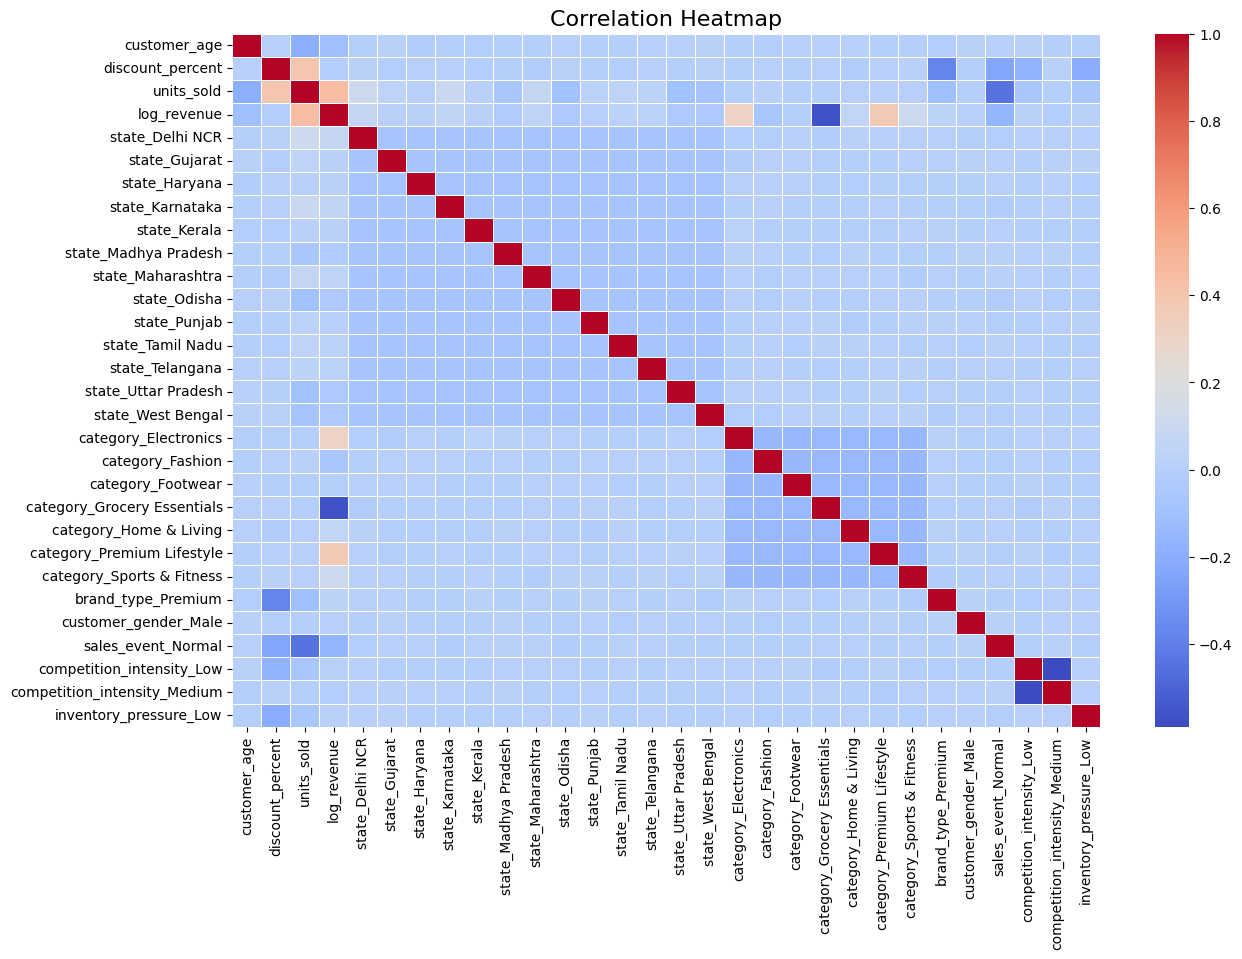

In [9]:
plt.figure(figsize=(14,9))
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Heatmap', fontsize=16)
plt.show()

## 6. Regression Modelling (OLS)
### Regression Modelling

An Ordinary Least Squares (OLS) regression model was used to quantify the relationship between revenue and its potential drivers. The dependent variable was log-transformed revenue, while independent variables included pricing, product categories, customer characteristics, and market conditions.

The regression model allows us to:

- Estimate the impact of each factor on revenue
- Identify statistically significant drivers
- Understand relative importance of different features

In [10]:
# OLS model 
import statsmodels.api as sm
X = df.drop(columns=['log_revenue','customer_age','state_Delhi NCR','state_Gujarat','state_Karnataka','state_Kerala','state_Madhya Pradesh'
                    ,'state_Maharashtra','state_Odisha','state_Punjab','state_Tamil Nadu','state_Uttar Pradesh','state_Telangana',
                    'state_West Bengal','brand_type_Premium','customer_gender_Male','competition_intensity_Low','competition_intensity_Medium',
                    'inventory_pressure_Low'])
y = df['log_revenue']

In [11]:
# add constant 
X = sm.add_constant(X)

In [12]:
# fit the model 
model = sm.OLS(y, X).fit()

In [13]:
# model summary 
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     9687.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:48:10   Log-Likelihood:                -27166.
No. Observations:               30600   AIC:                         5.436e+04
Df Residuals:                   30588   BIC:                         5.446e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

### 7. Model Diagnostics
## Model Diagnostics

To ensure the reliability of the regression model, several diagnostic checks were performed:

- Residual plots were analysed to assess linearity and homoscedasticity
- Normality of residuals was evaluated using Q-Q plots
- Multicollinearity was assessed using Variance Inflation Factor (VIF)
- Outliers and influential observations were analysed using Cook’s Distance

These diagnostics help validate the robustness of the model and ensure reliable interpretation.

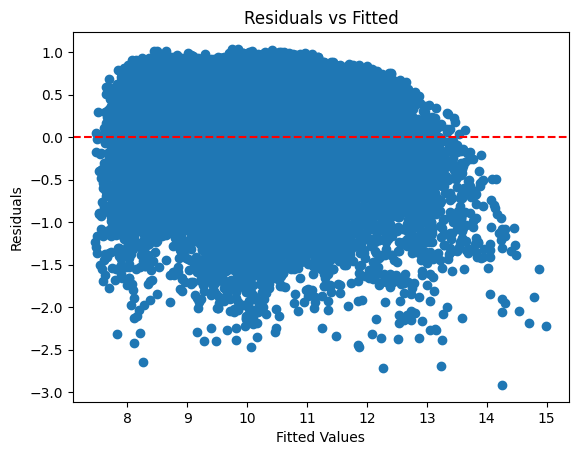

In [14]:
# 1. Residuals vs Fitted (Linearity + Homoscedasticity)
import matplotlib.pyplot as plt

fitted = model.fittedvalues
residuals = model.resid

plt.scatter(fitted, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

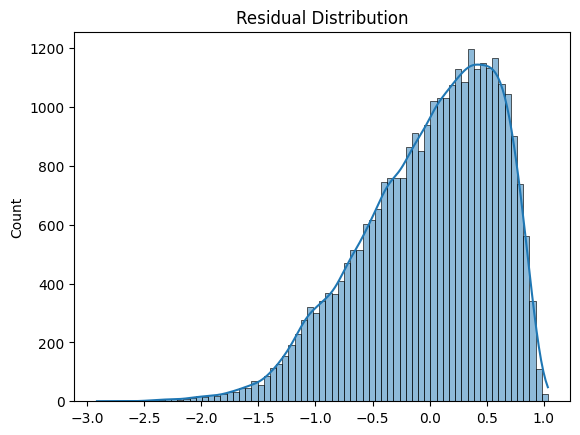

In [15]:
# Normality of Residuals
import seaborn as sns

sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.show()

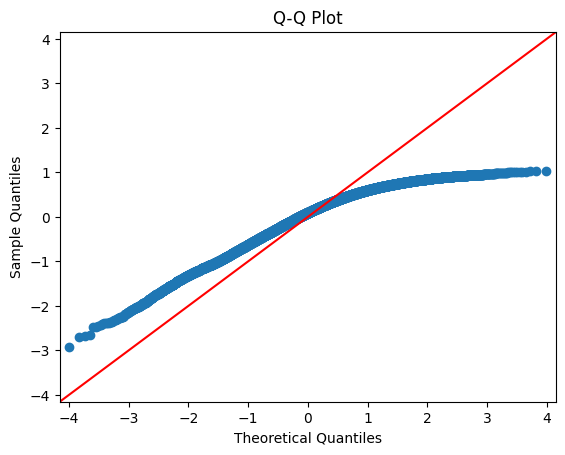

In [16]:
# Q-Q plot 
import statsmodels.api as sm

sm.qqplot(residuals, line='45')
plt.title('Q-Q Plot')
plt.show()

In [17]:
# 3. Test for Heteroscedasticity (Breusch-Pagan)
from statsmodels.stats.diagnostic import het_breuschpagan

test = het_breuschpagan(residuals, model.model.exog)

labels = ['Lagrange multiplier', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, test)))

{'Lagrange multiplier': np.float64(607.3146310421388), 'p-value': np.float64(3.8162429191980194e-123), 'f-value': np.float64(56.30627390947258), 'f p-value': np.float64(2.0280684477790165e-124)}


In [18]:
# 4. Multicollinearity (VIF)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif["Feature"] = model.model.exog_names
vif["VIF"] = [variance_inflation_factor(model.model.exog, i) 
              for i in range(model.model.exog.shape[1])]

print(vif)

                        Feature        VIF
0                         const  21.333682
1              discount_percent   1.191337
2                    units_sold   1.400364
3                 state_Haryana   1.000167
4          category_Electronics   1.718137
5              category_Fashion   1.721022
6             category_Footwear   1.721063
7   category_Grocery Essentials   1.712412
8        category_Home & Living   1.711336
9    category_Premium Lifestyle   1.708047
10    category_Sports & Fitness   1.727238
11           sales_event_Normal   1.251978


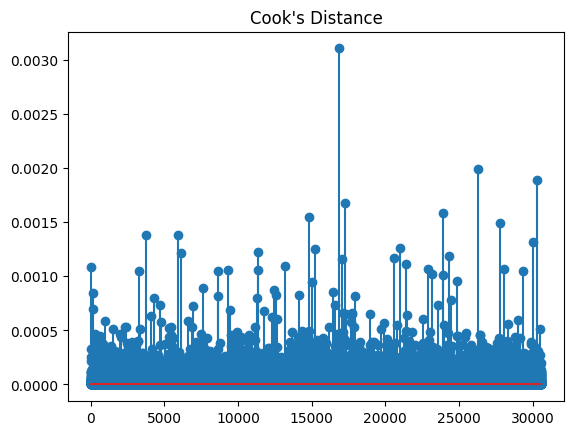

In [19]:
# 5. Outliers & Influential Points
influence = model.get_influence()
cooks = influence.cooks_distance[0]

plt.stem(cooks)
plt.title("Cook's Distance")
plt.show()

## 8. Key Insights (With Quantified Results)

The regression analysis provides the following key quantitative insights:

### 1. Quantity Sold is the strongest driver of revenue
- Each additional unit sold is associated with an approximate 3.1% increase in revenue (based on the log-revenue coefficient ≈ 0.031).
### 2. Premium product categories significantly outperform others
- Premium Lifestyle products generate approximately +197% higher revenue compared to the reference category (coefficient ≈ 1.97).
- Electronics contribute approximately +174% higher revenue (coefficient ≈ 1.74).
### 3. Discounting negatively impacts revenue
- A 1 percentage-point increase in discount is associated with approximately a 1.6% decrease in revenue (coefficient ≈ -0.016), suggesting that aggressive discounting may erode revenue rather than increase it.
### 4. Lower-value categories underperform
- Grocery Essentials show a ~113% lower revenue contribution compared to the baseline category (coefficient ≈ -1.13), indicating lower-value transactions.
### 5. Operational and market conditions matter
- Lower inventory pressure is associated with stronger revenue performance.
- Moderate competition levels show mixed effects on revenue performance.

These findings highlight that revenue growth is primarily driven by sales volume and product mix rather than discounting, offering actionable guidance for pricing and product strategy.

## 9. Limitations
### Limitations

While the model provides meaningful insights, there are limitations:

- The analysis assumes linear relationships between variables
- Some relationships may be non-linear or interactive
- External macroeconomic factors were not included
- Results reflect historical patterns and may not fully capture future dynamics

## 10. Future Work
### Future Work

Future enhancements could include:

- Exploring non-linear models such as tree-based methods
- Incorporating additional data sources
- Testing interaction effects between key variables
- Extending the analysis to customer lifetime value and segmentation